# New Workflow Component for Expanding Knowledge

This document introduces a proposed workflow enhancement, with **binning** as a case study to illustrate the justification for dataset reprocessing. Specifically, **Eukaryotic binning**, operational since **September 2022**, serves as an example.

## Summary of EukCC Bin Statistics and Taxonomic Distribution  

As of **January 23, 2025**, the following statistics have been compiled:

- **[Total Metagenomes with Bins: 25,146](https://img.jgi.doe.gov/cgi-bin/m/main.cgi?section=MetagenomeBins&page=bins&type=taxonomy)**  
- **Total Bins: 319,839**  
- **Total Metagenomes with EukCC Bins: 827**  
- **[Total EukCC Bins: 1,281](https://img.jgi.doe.gov/cgi-bin/m/main.cgi?section=MetagenomeBins&page=bindetail&taxonomy=ncbi&type=bytaxonomy&domain=Eukaryota&domain=Eukaryota%20EukCC%20Bins)**  

### Additional Notes  
The total number of EukCC bins has been exported as a TSV file (`data/exported_img_data-EukCC_bins.tsv`) using the IMG database link provided above. This file serves as a critical reference for downstream analyses.

---

## Analysis: EukCC Bin Counts per Metagenome  

An initial analysis was performed to evaluate the distribution of EukCC bins across metagenomes:  

- A histogram of EukCC bin counts per metagenome reveals that **most metagenomes contain a single EukCC bin**, with the maximum number of bins in a single metagenome being **9**.

---

## Analysis: EukCC Bin Taxonomy Distribution  

The taxonomy distribution analysis highlights a dominance of Eukaryota lineages. Key findings include:

- Significant representation of **Chlorophyta**, particularly within the **Mamiellophyceae** class and related orders.
- Prominent presence of **Ascomycota**, with notable classes such as **Lecanoromycetes**.  
- Recurring observations of fungal lineages such as **Basidiomycota** and **Tremellomycetes**.  

A **Sankey diagram** has been generated to visualize hierarchical taxonomic connections. The diagram illustrates the flow from higher-order taxa (e.g., **Eukaryota**) to specific families and genera, emphasizing dominant relationships and abundances within the dataset. 

A **Krona plot** provided another perspective to view the taxnomy distribution which is run through KronaTools v2.8.1 and can be generated by following command lines:

```js
awk -F"\t" '{print $5}' data/exported_img_data-EukCC_bins.txt  | sed -e 's/; /\t/g' | tail -n+2 > exported_img_data-EukCC_bins_for_krona.txt
ktImportText -q -o data/EukCC.krona.html exported_img_data-EukCC_bins_for_krona.txt 

```

---

## Conclusion  

This analysis demonstrates the value of reprocessing datasets with the proposed workflow component. By systematically updating processing methodologies, we can ensure more accurate and comprehensive insights into eukaryotic binning trends, enabling improved knowledge discovery and resource utilization.


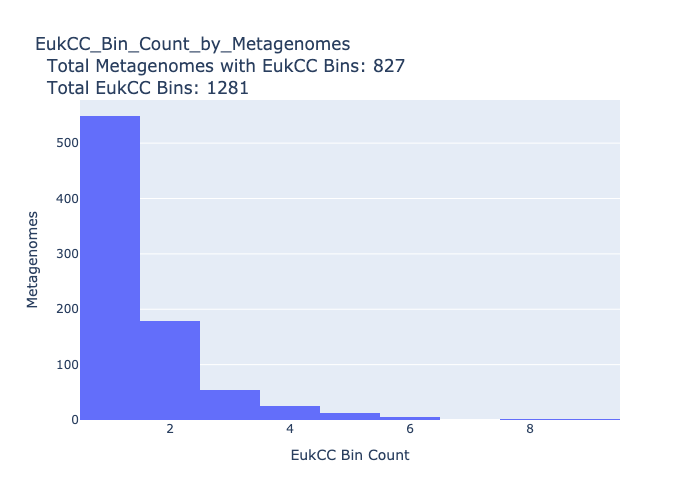

In [2]:
#Analysis: EukCC Bin Counts per Metagenome
import plotly.io as pio
pio.renderers.default = 'png'
import pandas as pd
import plotly.express as px

# Load the data
file_path = 'data/exported_img_data-EukCC_bins.tsv'
data = pd.read_csv(file_path, sep='\t')

total_EukCC_bins = len(data['IMG Genome ID'])
total_mtg_with_EukCC_bins = len(data['IMG Genome ID'].unique())

fig = px.histogram(
        data.groupby('IMG Genome ID')['bin_oid'].count(),
        title=f'EukCC_Bin_Count_by_Metagenomes<br>  Total Metagenomes with EukCC Bins: {total_mtg_with_EukCC_bins} <br>  Total EukCC Bins: {total_EukCC_bins}',
    )
fig.update_layout(xaxis_title='EukCC Bin Count', yaxis_title='Metagenomes',showlegend=False)
fig.show(renderer="png")

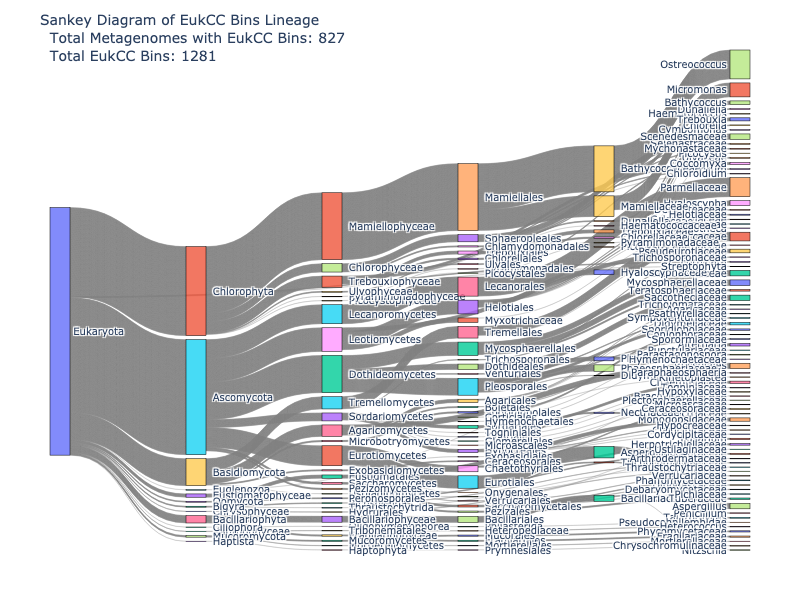

In [3]:
#Analysis: EukCC Bin Taxonomy Distribution  
import plotly.graph_objects as go

# Extract relevant columns for Sankey diagram from the above data
lineages = data['Bin Lineage'].dropna()
# Split lineages into hierarchical components
hierarchies = lineages.str.split(';')

# Create unique node labels
node_labels = list(set([level for lineage in hierarchies for level in lineage]))
node_indices = {label: idx for idx, label in enumerate(node_labels)}

# Generate Sankey diagram links
source = []
target = []
values = []

for lineage in hierarchies:
    for i in range(len(lineage) - 1):
        source.append(node_indices[lineage[i]])
        target.append(node_indices[lineage[i + 1]])
        values.append(1)  # Each occurrence adds a count

# Create the Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels
    ),
    link=dict(
        source=source,
        target=target,
        value=values,
        color="rgba(128,128,128, 0.2)",
        hovercolor="midnightblue"
    )
))

fig.update_layout(title_text=f"Sankey Diagram of EukCC Bins Lineage<br>  Total Metagenomes with EukCC Bins: {total_mtg_with_EukCC_bins} <br>  Total EukCC Bins: {total_EukCC_bins}", font_size=10, width=800,
    height=600, margin=dict(l=50, r=50, t=50, b=50))
fig.show(renderer="png")

# How much does the functional annotation assignment change

### We will use following dataset among the various versions of annotation workflows and count [KO assignment](https://www.genome.jp/kegg/ko.html) for the initial analysis: 
#### SPRUCE
- **NMDC Study ID:** `nmdc:sty-11-33fbta56` / **GOLD Study ID:** `Gs0110138`  
At a minimum, we have recent re-annotations using version 5.2 (the latest version), both done with SPAdes. Time permitting, there are older records from earlier versions of SPAdes and the older MEGAHIT workflow (circa 2016/2017).

#### STEGEN Riverbed Sediment
- **NMDC Study ID:** `nmdc:sty-11-aygzgv51` / **GOLD Study ID:** `Gs0114663`  
Similar to SPRUCE, we have recent re-annotations done with SPAdes. Older records also exist, using earlier versions of SPAdes and the older MEGAHIT workflow.

#### CRESTED BUTTE
- **NMDC Study ID:** `nmdc:sty-11-dcqce727` / **GOLD Study ID:** `Gs0135149`  
Assemblies were created using MetaSPAdes v3.13.0 with annotation version v5.0.20 versus v5.2.0. Some older records were generated using SPAdes v3.11.1 with annotation version v4.16.4.

#### POPULUS
- **NMDC Study ID:** `nmdc:sty-11-1t150432` / **GOLD Study ID:** `Gs0103573`  
It includes both MEGAHIT and SPAdes assemblies. According to the data, NMDC reannotated the MEGAHIT assemblies in 2022, and we reran the annotation in 2024. Consider excluding this dataset if we have sufficient other data for analysis.

#### WET TROPICAL SOIL
- **NMDC Study ID:** `nmdc:sty-11-076c9980` / **GOLD Study ID:** `Gs0128850`  
Assemblies were created using SPAdes v3.12.0 or v3.13.0 with annotation version v4.16.5. NMDC reannotated the data with version 5.2.


### Dataset retrieval and staging
1. To get the most recent NMDC data, the mongo db.aggregate is performed to get Gold biosample ID, OMICS_PROCESSING_ID, workflow_execution_set IDs. 

- Here is an example for mongo db aggregation with SPRUCE dataset:
```js
        db.getCollection(
            'data_generation_set'
        ).aggregate(
        [
            {
                $match: {
                associated_studies: "nmdc:sty-11-33fbta56",
                analyte_category: "metagenome"
                }
            },
            {
                $lookup: {
                from: "biosample_set",
                localField: "has_input",
                foreignField: "id",
                as: "biosample_set"
                }
            },{
                    $lookup: {
                from: "workflow_execution_set",
                localField: "id",
                foreignField: "was_informed_by",
                as: "workflow_execution_set"
                }
            }
        ]
```
* The NMDC processed data will be on nersc at /global/cfs/cdirs/m3408/results/$OMICS_PROCESSING_ID/$workflow_execution_set_id.  The data will be symlink to staging area and using GOLD biosample ID(ex: `/global/cfs/cdirs/m3408/squads/reprocessing_samples/data/SPRUCE/Gb0139004`) as a subdirectory name. 

2. To Get older workflow version processed result from JGI/IMG, the [Gold API](https://gold-ws.jgi.doe.gov) and biosample ID from previous step to query analysis_projects to get ITSapID and IMG taxonOID. Using either ITSapID or IMG taxonOID, we use `jamo report` and `jamo fetch` commands to restore th PURGED/ARCHIVED annoation tar.gz files. 

- Here is an example of cmds using IMG taxonOID 3300009759:
```bash
    taxon_oid=3300009759
    ID=`jamo report select file_name,file_path,file_status,_id  where metadata.img.taxon_oid=$taxon_oid | grep gz| grep -E [0-9][0-9][0-9][0-9].tar.gz | grep PURGED | awk '{print $4}'` 
    if [ ! -z "${ID}" ]
    then
    jamo fetch id $ID
    fi
```
- Wait for the data been restored, we can then tar unzip data to staging area and using GOLD biosample ID(ex: Gb0139004) as a subdirectory name
```bash
    file=`jamo report select file_name,file_path,file_status,_id  where metadata.img.taxon_oid=$taxon_oid | grep gz| grep -E [0-9][0-9][0-9][0-9].tar.gz | awk '{print $2"/"$1}'` 
    tar -xvzf $file -C /global/cfs/cdirs/m3408/squads/reprocessing_samples/data/SPRUCE/Gb0139004
```

#### Notes
- Some samples from populus and spruce study have missing with the annotation version info from GOLD database, through the IMG web interface ([GenomeCart](https://img.jgi.doe.gov/cgi-bin/m/main.cgi?section=GenomeCart&page=genomeCart)) by uploading a list of IMG taxonOID and select the `IMG Release/Pipeline Version` to display. 
- There is issue on Gb0191677(crested) that `/global/cfs/cdirs/m3408/results/nmdc:omprc-11-0p5zak44/nmdc:wfmgan-11-6sa4k759.1/nmdc_wfmgan-11-6sa4k759.1_functional_annotation.gff` file size is too small: copy data issue?
    ```bash
    > wc -l nmdc:wfmgan-11-6sa4k759.1/*annotation.gff
        67381 nmdc:wfmgan-11-6sa4k759.1/nmdc_wfmgan-11-6sa4k759.1_functional_annotation.gff
      4236790 nmdc:wfmgan-11-6sa4k759.1/nmdc_wfmgan-11-6sa4k759.1_structural_annotation.gff
    ```

### Calculate run time of the annotation workflow

Only NMDC processed samples have metadata.json file which we can capture the runtime (use `jq`) and we also grep the total input contigs base paired for runtime normalization.

```bash
for j in stegen crested populus wet_tropical_soil SPRUCE
do
cd /global/cfs/cdirs/m3408/squads/reprocessing_samples/data/$j
  for i in */*/metadata.json; 
    do 
      dir=`dirname $i`; 
      echo -en "$dir\t";  
      contig_bp=`grep final_fasta $dir/*stats.tsv| awk '{print $3}'`
      echo -en "$contig_bp\t";
      jq -r '(.end | sub("\\..*Z$"; "Z") | fromdate) - (.start | sub("\\..*Z$"; "Z") | fromdate)' $i; 
    done > ${j}_nmdc_annoation_runtime_in_sec.txt
done
```

### Output for Each Study Dataset:
- `data/SPRUCE_nmdc_annoation_runtime_in_sec.txt`
- `data/populus_nmdc_annoation_runtime_in_sec.txt`
- `data/stegen_nmdc_annoation_runtime_in_sec.txt`
- `data/wet_tropical_soil_nmdc_annoation_runtime_in_sec.txt`
- `data/crested_nmdc_annoation_runtime_in_sec.txt`

### Output Columns:
1. sample name
2. contig total bases
3. runtime in second

### Summary
- Overall average runtime across all datasets is 3015.35 minutes =~ 50 hrs (± 1493.33 min).
- Overall average normalized runtime is 9.08 min/Mbp (± 17.15 min/Mbp).
- Large variability in both overall runtime and normalized runtime suggests that some datasets require significantly more time for annotation, possibly due to differences in sequencing depth, complexity, or computational workload.
- Caveat: The runtime in meta_data.json includes queue wait time and won't include how much resources were used and such it may not reflect the real time usage. It would be more useful to look at the condor logs in the future. From previous testing, the longest parts are **rfam** and **lastal**.

In [1]:
# This code block is used to generate the summary table for the annoation runtime analysis

import pandas as pd

# Load the data
crested_df = pd.read_csv("data/crested_nmdc_annoation_runtime_in_sec.txt", sep="\t", header=None, names=["Sample", "Total_Bases", "Runtime"])
spruce_df = pd.read_csv("data/SPRUCE_nmdc_annoation_runtime_in_sec.txt", sep="\t", header=None, names=["Sample", "Total_Bases", "Runtime"])
stegen_df = pd.read_csv("data/stegen_nmdc_annoation_runtime_in_sec.txt", sep="\t", header=None, names=["Sample", "Total_Bases", "Runtime"])
populus_df = pd.read_csv("data/populus_nmdc_annoation_runtime_in_sec.txt", sep="\t", header=None, names=["Sample", "Total_Bases", "Runtime"])
wet_tropical_soil_df = pd.read_csv("data/wet_tropical_soil_nmdc_annoation_runtime_in_sec.txt", sep="\t", header=None, names=["Sample", "Total_Bases", "Runtime"])

# Calculate normalized runtime (sec per 1 Mbp)
crested_df["Normalized_Runtime"] = (crested_df["Runtime"] / crested_df["Total_Bases"]) * 1_000_000
spruce_df["Normalized_Runtime"] = (spruce_df["Runtime"] / spruce_df["Total_Bases"]) * 1_000_000
stegen_df["Normalized_Runtime"] = (stegen_df["Runtime"] / stegen_df["Total_Bases"]) * 1_000_000
populus_df["Normalized_Runtime"] = (populus_df["Runtime"] / populus_df["Total_Bases"]) * 1_000_000
wet_tropical_soil_df["Normalized_Runtime"] = (wet_tropical_soil_df["Runtime"] / wet_tropical_soil_df["Total_Bases"]) * 1_000_000

# Convert runtime to minutes
crested_avg_runtime_min = crested_df["Runtime"].mean() / 60
crested_std_runtime_min = crested_df["Runtime"].std() / 60

spruce_avg_runtime_min = spruce_df["Runtime"].mean() / 60
spruce_std_runtime_min = spruce_df["Runtime"].std() / 60

stegen_avg_runtime_min = stegen_df["Runtime"].mean() / 60
stegen_std_runtime_min = stegen_df["Runtime"].std() / 60

populus_avg_runtime_min = populus_df["Runtime"].mean() / 60
populus_std_runtime_min = populus_df["Runtime"].std() / 60

wet_tropical_soil_avg_runtime_min = wet_tropical_soil_df["Runtime"].mean() / 60
wet_tropical_soil_std_runtime_min = wet_tropical_soil_df["Runtime"].std() / 60

# Convert normalized runtime to minutes
crested_avg_norm_runtime_min = crested_df["Normalized_Runtime"].mean() / 60
crested_std_norm_runtime_min = crested_df["Normalized_Runtime"].std() / 60

spruce_avg_norm_runtime_min = spruce_df["Normalized_Runtime"].mean() / 60
spruce_std_norm_runtime_min = spruce_df["Normalized_Runtime"].std() / 60

stegen_avg_norm_runtime_min = stegen_df["Normalized_Runtime"].mean() / 60
stegen_std_norm_runtime_min = stegen_df["Normalized_Runtime"].std() / 60

populus_avg_norm_runtime_min = populus_df["Normalized_Runtime"].mean() / 60
populus_std_norm_runtime_min = populus_df["Normalized_Runtime"].std() / 60

wet_tropical_soil_avg_norm_runtime_min = wet_tropical_soil_df["Normalized_Runtime"].mean() / 60
wet_tropical_soil_std_norm_runtime_min = wet_tropical_soil_df["Normalized_Runtime"].std() / 60

# Create a summary dataframe
summary_df = pd.DataFrame({
    "Dataset": ["Crested", "Spruce", "Stegen", "Populus", "Wet Tropical Soil"],
    "Sample Count" : [len(crested_df), len(spruce_df), len(stegen_df), len(populus_df), len(wet_tropical_soil_df)],
    "Avg Runtime (min)": [crested_avg_runtime_min, spruce_avg_runtime_min, stegen_avg_runtime_min, populus_avg_runtime_min, wet_tropical_soil_avg_runtime_min],
    "Std Runtime (min)": [crested_std_runtime_min, spruce_std_runtime_min, stegen_std_runtime_min, populus_std_runtime_min, wet_tropical_soil_std_runtime_min],
    "Avg Normalized Runtime (min)": [crested_avg_norm_runtime_min, spruce_avg_norm_runtime_min, stegen_avg_norm_runtime_min, populus_avg_norm_runtime_min, wet_tropical_soil_avg_norm_runtime_min],
    "Std Normalized Runtime (min)": [crested_std_norm_runtime_min, spruce_std_norm_runtime_min, stegen_std_norm_runtime_min, populus_std_norm_runtime_min, wet_tropical_soil_std_norm_runtime_min]
})

summary_df

,Dataset,Sample Count,Avg Runtime (min),Std Runtime (min),Avg Normalized Runtime (min),Std Normalized Runtime (min)
0,Crested,48,5218.371528,1691.559600,5.673362,2.857612
1,Spruce,107,3325.130218,634.330623,6.295385,3.225267
2,Stegen,50,2130.899667,60.194701,35.743858,23.866260
3,Populus,29,3160.221839,1641.397384,6.917026,30.439030
4,Wet Tropical Soil,103,2055.437217,1078.706642,1.210566,0.779218


### Counting Unique KO Numbers, Total KO Numbers, and Total Features

A script, `get_ko_numbers.py`, is used to count the **Unique KO number**, **Total KO number**, and **Total features number** for each dataset in the directory:

/global/cfs/cdirs/m3408/squads/reprocessing_samples/data 

The results are saved as tab-delimited `{studyName}_stats.tsv` files for each dataset in [the repository](https://github.com/microbiomedata/nmdc_notebooks/tree/data_reprocessing_analysis/data_reprocessing_analysis/python/data).

#### Running the Script

To execute the script for a specific dataset, use the following command:

```bash
./get_ko_numbers.py -d /global/cfs/cdirs/m3408/squads/reprocessing_samples/data/SPRUCE
```

### Output for Each Study Dataset:
- `data/SPRUCE_stats.tsv`
- `data/populus_stats.tsv`
- `data/stegen_stats.tsv`
- `data/wet_tropical_soil_stats.tsv`
- `data/crested_stats.tsv`

### Output Header:
1. **Unique_KO_count**  
   The count of unique KO numbers in the `sample_ko.tsv` annotation file.  

2. **Total_KO_count**  
   The total gene count with KO number assignments in the `sample_ko.tsv` annotation file.  

3. **Total_features_count**  
   The total number of features annotated in the `sample_functional_annotation.gff` file.  


In [ ]:
# This script will consolidate each study's output from get_ko_numbers.py into a single file.
# The script will also calculate the ratio of unique KOs to total features and the ratio of total KOs to total features for each study.
# The script will also calculate the difference in these counts and ratios between adjacent pipeline versions.
# adding a column for the study name and filling in missing values with zeros.
# The output file will be saved as 'Merged_stats_with_ratios_and_diff.tsv' in the 'data' directory. 
import pandas as pd
import plotly.express as px
df = pd.DataFrame()

# List of pipeline versions
versions = [
    "IMG Annotation Pipeline v.5.0.20 [Metaspades v. 3.13.0]",
    "NMDC version of IMG Annotation Pipeline v.5.0.25 [metaSPAdes v. 3.15.0]",
    "IMGAP Version: 5.2.0 [metaSPAdes v. 3.15.0]",
   #"Unknown"
]

# Function to create difference columns between two versions
def create_diff_columns(df, v1, v2):
    for metric in ['Unique_KO_count', 'Total_KO_count', 'Total_features_count','Unique_KO_ratio','Total_KO_ratio']:
        col_name = f"{v2}_{v1}_{metric}_diff"
        df[col_name] = df[f"{v2} {metric}"] - df[f"{v1} {metric}"]
    return df

# Function to create ratio columns for a given pipeline version
def create_ratio_columns(df, version):
    # Create column names
    unique_ratio_col = f"{version} Unique_KO_ratio"
    total_ratio_col = f"{version} Total_KO_ratio"
    
    # Calculate ratios
    df[unique_ratio_col] = df[f"{version} Unique_KO_count"] / df[f"{version} Total_features_count"]
    df[total_ratio_col] = df[f"{version} Total_KO_count"] / df[f"{version} Total_features_count"]
    
    return df

for i in ['crested','SPRUCE','populus','stegen','wet_tropical_soil']:
    file_path = f'data/{i}_stats.tsv'
    data_raw = pd.read_csv(file_path, sep='\t', header=None)
    headers = ['Gold_biosample ' ] + [ header.split(';')[1].replace('\"','') + f" [{header.split(';')[0]}] " for header in data_raw.iloc[0]  if header != 'Gold_biosampple' ] 
    headers = [a+b for a, b in zip(headers, data_raw.iloc[1])]
    data_merged = pd.read_csv(file_path, sep='\t', header=1)
    data_merged.columns = headers
    data_merged['env'] = i
    df = pd.concat([df,data_merged],ignore_index=True, sort=False)
    # Create difference columns for adjacent versions 
    # Create ratio columns for each version
    relevant_versions = [col for col in versions if any(col in head for head in data_merged.columns)]
    #print('env:' + i)
    #print(relevant_versions)
   
    for i in relevant_versions:
        df = create_ratio_columns(df, i)
    for i in range(len(relevant_versions) - 1):
        
        df = create_diff_columns(df, relevant_versions[i], relevant_versions[i+1])

# Reorder the columns
df = df.reindex(sorted(df.columns), axis=1)
# Save the updated dataframe to a new tab-delimited file
df.to_csv('data/Merged_stats_with_ratios_and_diff.txt', sep='\t', index=False)


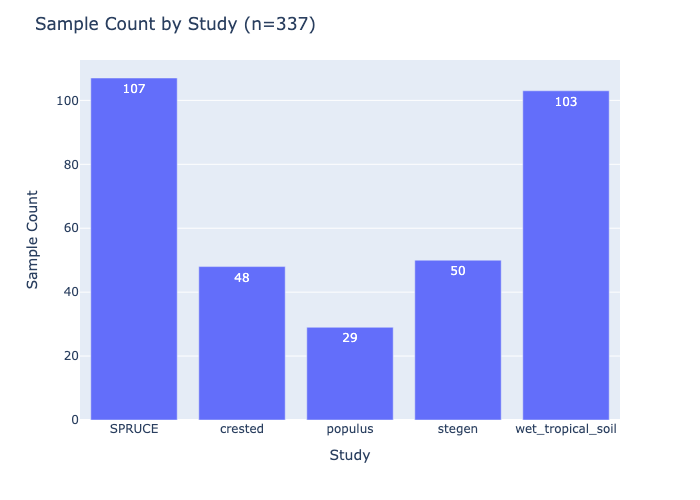

In [2]:
# Sample Count by Study
sample_count_df=df.groupby('env').count()['Gold_biosample ID'] 
import plotly.io as pio
pio.renderers.default = 'png'

fig=px.bar(sample_count_df,text_auto=True)
fig.update_layout(yaxis_title='Sample Count',xaxis_title='Study',title=f'Sample Count by Study (n={sample_count_df.sum()})',showlegend=False)
fig.show(renderer="png")


In [6]:
# This section perform the following steps:
#1. Filter relevant columns
#2. Melt the dataframe
#3. Extract the metric from the 'Metric_Pipeline' column
#4. Extract the pipeline version from the 'Metric_Pipeline' column
#5. Add counts of samples to pipeline labels
#6. Clean the dataframe by removing rows with missing values in 'Pipeline' and 'Value' columns

#Filter relevant columns
relevant_columns = [col for col in df.columns if not any(metric in col for metric in ['Unknown'])]
filtered_data = df[relevant_columns]

# Melt the dataframe
melted_data = filtered_data.melt(id_vars=['Gold_biosample ID','env'], var_name='Metric_Pipeline', value_name='Value')
melted_data['Metric'] = melted_data['Metric_Pipeline'].str.extract(r'(Unique_KO_count_diff|Unique_KO_count|Total_KO_count_diff|Total_KO_count|Total_features_count_diff|Total_features_count|Unique_KO_ratio_diff|Total_KO_ratio_diff|Unique_KO_ratio|Total_KO_ratio)')
tmp = melted_data['Metric_Pipeline'].str.findall(r'(v\.\d+\.\d+\.\d+ \[.*?\]|Version: \d+\.\d+\.\d+ \[.*?\])')
melted_data['Pipeline']  = tmp.apply(lambda x: '_'.join(i for i in x).replace('Version: ', 'v.').replace('Metaspades', '♠').replace('metaSPAdes', '♠').replace('spades', '♠').replace(' v. ', ''))
#melted_data['Assembler']=melted_data['Metric_Pipeline'].str.extract(r'(\[.*\])')
# Add counts of samples to pipeline labels
sample_counts = melted_data.groupby('Metric_Pipeline')['Value'].count().to_dict()
melted_data['Pipeline_sample_count'] = melted_data['Metric_Pipeline'].map(
    lambda x: f"({sample_counts.get(x, 0)})"
)
melted_data['Pipeline_with_count'] = melted_data['Pipeline'] + melted_data['Pipeline_sample_count']

# clean the dataframe by removing rows with missing values in 'Pipeline' and 'Value' columns
cleaned_data = melted_data.dropna(subset=['Pipeline','Value'])
cleaned_data.head()


,Gold_biosample ID,env,Metric_Pipeline,Value,Metric,Pipeline,Pipeline_sample_count,Pipeline_with_count
157,Gb0115853,populus,IMG Annotation Pipeline v.4.11.0 [MEGAHIT v. 1...,3890208.0,Total_KO_count,v.4.11.0 [MEGAHIT1.0.3],(5),v.4.11.0 [MEGAHIT1.0.3](5)
161,Gb0115854,populus,IMG Annotation Pipeline v.4.11.0 [MEGAHIT v. 1...,3197464.0,Total_KO_count,v.4.11.0 [MEGAHIT1.0.3],(5),v.4.11.0 [MEGAHIT1.0.3](5)
170,Gb0115863,populus,IMG Annotation Pipeline v.4.11.0 [MEGAHIT v. 1...,3263337.0,Total_KO_count,v.4.11.0 [MEGAHIT1.0.3],(5),v.4.11.0 [MEGAHIT1.0.3](5)
173,Gb0115849,populus,IMG Annotation Pipeline v.4.11.0 [MEGAHIT v. 1...,2894686.0,Total_KO_count,v.4.11.0 [MEGAHIT1.0.3],(5),v.4.11.0 [MEGAHIT1.0.3](5)
178,Gb0115858,populus,IMG Annotation Pipeline v.4.11.0 [MEGAHIT v. 1...,3292691.0,Total_KO_count,v.4.11.0 [MEGAHIT1.0.3],(5),v.4.11.0 [MEGAHIT1.0.3](5)


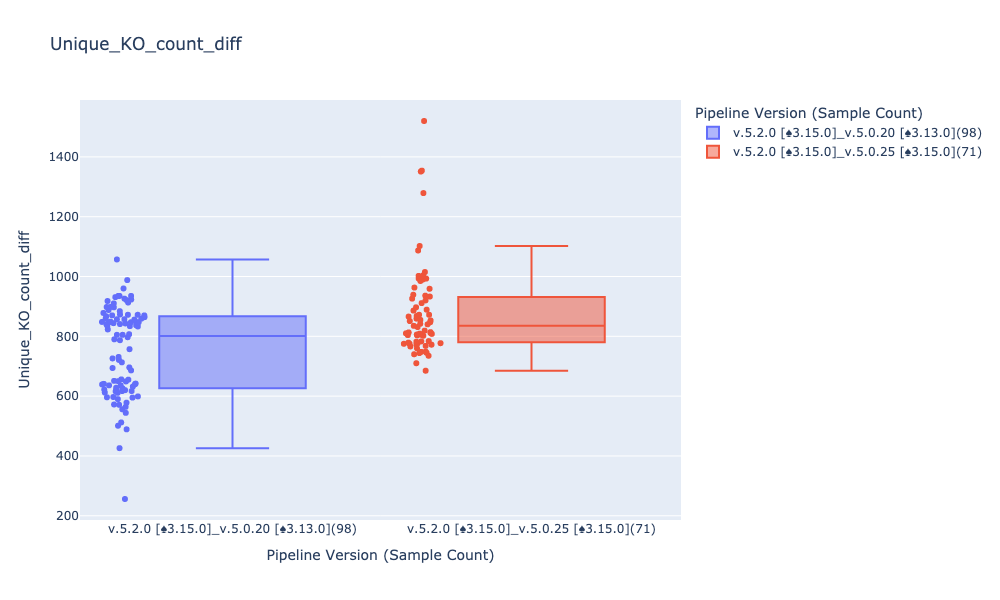

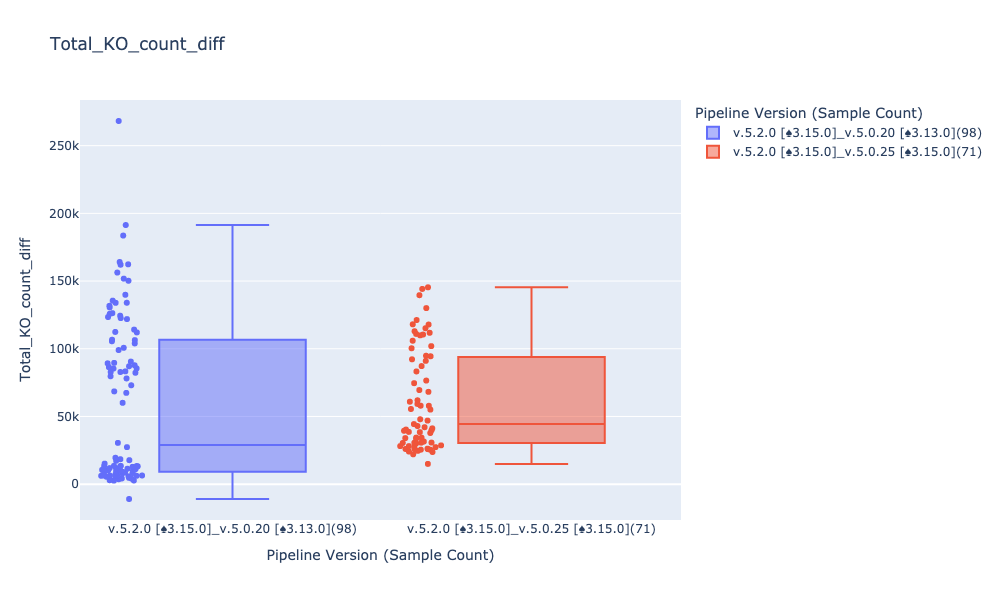

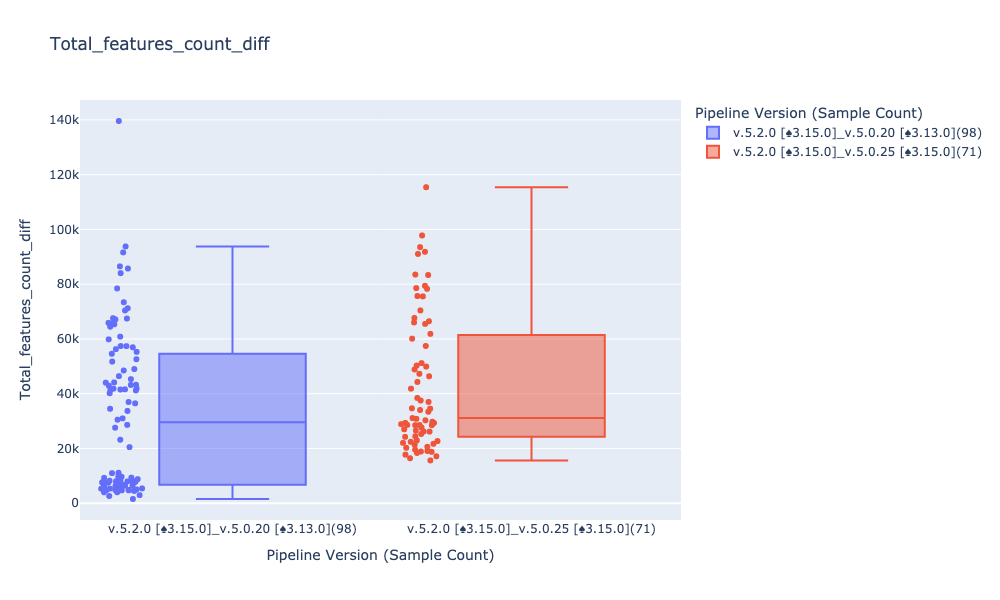

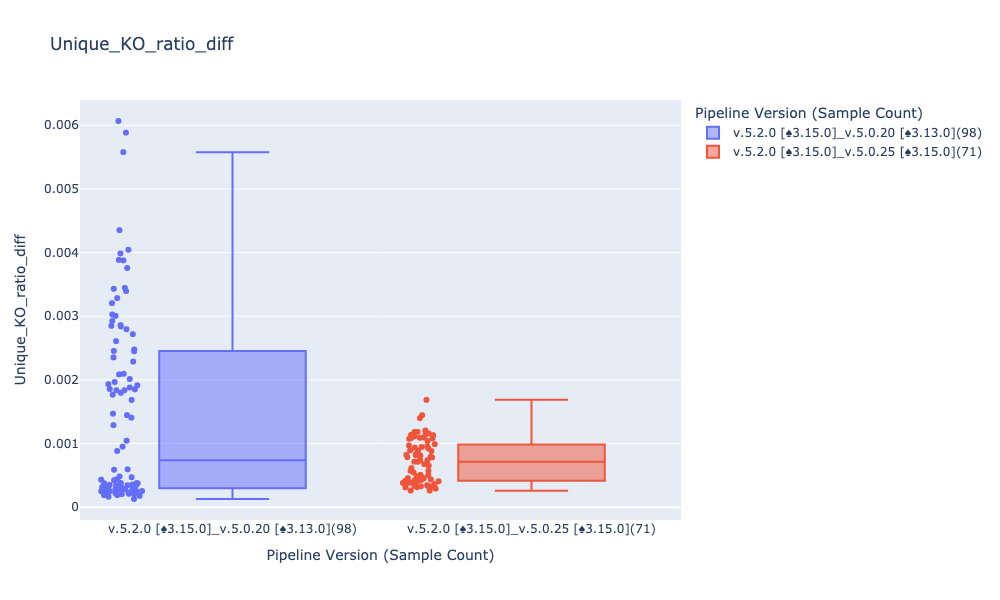

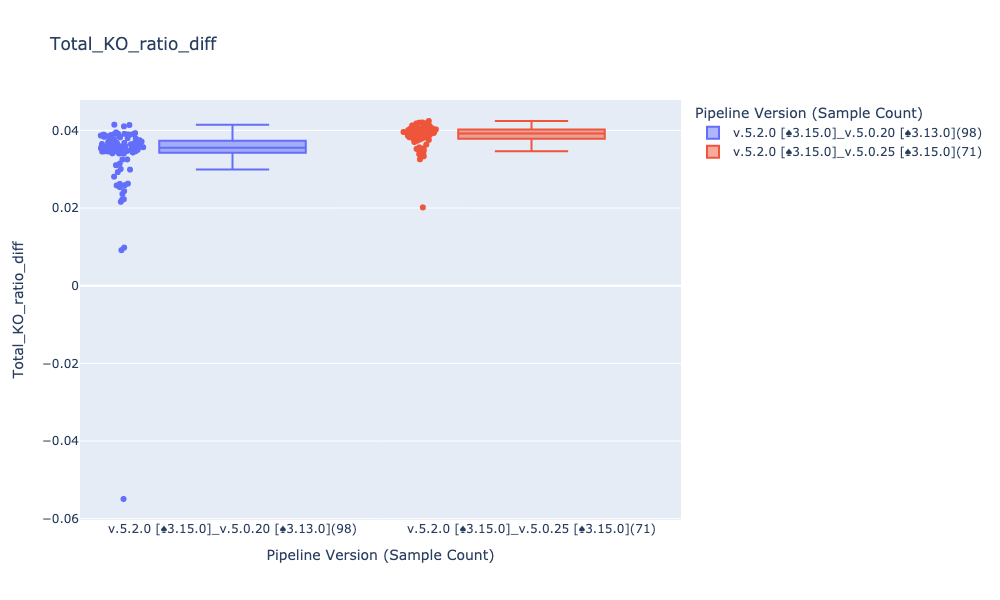

In [7]:
# This script will perform the following steps:
#1. Create box plots to visualize the metric values across pipeline versions.

from scipy.stats import f_oneway, ttest_ind
from itertools import combinations

results = {}
for metric in ['Unique_KO_count_diff', 'Total_KO_count_diff', 'Total_features_count_diff','Unique_KO_ratio_diff','Total_KO_ratio_diff']:
    metric_data = cleaned_data[cleaned_data['Metric'] == metric]

    fig = px.box(
        metric_data,
        x='Pipeline_with_count',
        y='Value',
        color='Pipeline_with_count',
        title=f"{metric}",
        labels={"Value": metric, "Pipeline_with_count": "Pipeline Version (Sample Count)"},
        points="all",
    )
    fig.update_layout(width=1000, height=600)

    fig.show(renderer="png")



## Considerations for Reprocessing Samples After a Workflow Update - 1

Determining a specific threshold for reprocessing all samples when a new version of the annotation workflow is released can be challenging. Here are some thoughts and can be expanded or adjusted with further discussion:

A practical approach is to set a threshold based on key metrics, such as:
- A **10% increase** in `Total_KO_count`
- A **0.04 difference** in `Total_KO_ratio`

Reprocessing should only be triggered if changes exceed this threshold. Conversely, if `Total_KO_ratio` changes are **less than 0.01** for most samples, this could justify skipping reprocessing.

### Additional Factors to Consider:
1. **Critical Updates**  
   If the pipeline update significantly improves annotation quality or introduces essential new features, reprocessing may be necessary.

2. **Age of Annotations**  
   Older annotations, particularly those generated before major pipeline updates (e.g., prior to v5.0.0), may benefit more from reprocessing.

3. **Dataset Importance**  
   High-priority or frequently accessed datasets should be considered for reprocessing with the latest pipeline version.

4. **User Requests**  
   NMDC can allow users to request reannotation of specific metagenomes or metatranscriptomes using the most recent pipeline version.


### To Do:

✅ list of annotation pipeline versions and their components from the info files. see [data/annotation_versions.xlsx](https://github.com/microbiomedata/nmdc_notebooks/blob/data_reprocessing_analysis/data_reprocessing_analysis/python/data/annotation_versions.xlsx)

✅ separate the above annotation compariosn box plot with different assembler used.

✅ Runtime analysis

☐ compare various Assemblies by tools update, MEGAHIT -> metaSPAdes or SPAdes version updated.

☐ meet biweekly


# How much does the Assembly result change?

### We will use same dataset from the annotation KO analysis.

1. We run [Quast](https://quast.sourceforge.net) on the assembly contig files to get the assembly statistical numbers, including total contig number, contig size, auN(areas under the Nx) etc for each biosample. 

    Example cmd:
    ```bash
    dir=/global/cfs/cdirs/m3408/squads/reprocessing_samples/data/SPRUCE/Gb0139004
    quast -o $dir/quast --fast --silent $dir/*/*.a.fna $dir/*/*_contigs.fna 
    ```
    The output `quast/transposed_report.tsv` will be used for the next step.

2. A custom script, `get_asm_stats.py`, is used to consolidate the assembly stats for each dataset in the directory:

    /global/cfs/cdirs/m3408/squads/reprocessing_samples/data 

    The results are saved as tab-delimited `{studyName}_asm_stats.tsv` files for each dataset in [the repository](https://github.com/microbiomedata/nmdc_notebooks/tree/data_reprocessing_analysis/data_reprocessing_analysis/python/data).

    #### Running the Script

    To execute the script for a specific dataset, use the following command:

    ```bash
    ./get_asm_stats.py -d /global/cfs/cdirs/m3408/squads/reprocessing_samples/data/SPRUCE
    ```

    ### Output for Each Study Dataset:
    - `data/SPRUCE_asm_stats.tsv`
    - `data/populus_asm_stats.tsv`
    - `data/stegen_asm_stats.tsv`
    - `data/wet_tropical_soil_asm_stats.tsv`
    - `data/crested_asm_stats.tsv`

    ### Output Header:
    1. **Total_contigs_number**  
    2. **Total_contigs_size (bp)**  
    3. **Contigs_number(>500bp)**  
    4. **Contigs_size(>500bp)**
    5. **Contigs_number(>1000bp)**
    6. **Contigs_size(>1000bp)**
    7. **Largest_contig_size**
    8. **auN**:  the areas under the Nx to summarize assembly contiguity with a single number. This metric was proposed and justified by Heng Li in [his blog](https://lh3.github.io/2020/04/08/a-new-metric-on-assembly-contiguity).



In [ ]:
# This script will consolidate each study's output from get_asm_stats.py into a single file.
# The script will also calculate the ratio in these numbers between adjacent pipeline versions.  (v2 - v1) / v1
# adding a column for the study name and filling in missing values with zeros.
# The output file will be saved as 'Merged_asm_stats_with_diff_ratios.tsv' in the 'data' directory. 


import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

ser = pd.DataFrame()

# List of pipeline versions
versions = [
 'MEGAHIT v. 0.2.0',
 'MEGAHIT v. 1.0.3',
 'MEGAHIT v. 1.0.6',
 'spades v. 3.11.1',
 'spades v. 3.12.0',
 'spades v. 3.13.0',
 'Metaspades v. 3.13.0',
 'metaSPAdes v. 3.15.0'
]

# Function to create difference columns between two versions
def create_diff_ratio_columns(df, v1, v2):
    for metric in ['Total_contigs_number', 'Contigs_number(>500bp)', 'Contigs_number(>1000bp)','Total_contigs_size (bp)','Contigs_size(>500bp)','Contigs_size(>1000bp)','Largest_contig_size','auN']:
        col_name = f"{v2}_{v1}_{metric}_diff_ratio"
        df[col_name] = (df[f"{v2} {metric}"] - df[f"{v1} {metric}"])/df[f"{v1} {metric}"]
    return df
asm_version = {}
for i in ['crested','SPRUCE','populus','stegen','wet_tropical_soil']:
    file_path = f'data/{i}_asm_stats.tsv'
    data_raw = pd.read_csv(file_path, sep='\t', header=None)
    headers = data_raw.iloc[0] + " " + data_raw.iloc[1]
    asm_version.update(data_raw.iloc[0].to_dict())
    data_merged = pd.read_csv(file_path, sep='\t', header=1)
    data_merged.columns = headers
    data_merged['env'] = i
    ##print(len(data_merged))
    ser = pd.concat([ser,data_merged],ignore_index=True, sort=False)
    # Create difference columns for adjacent versions
    relevant_versions = [col for col in versions if any(head.startswith(col) for head in data_merged.columns)]
    for i in range(len(relevant_versions) - 1):
        df = create_diff_ratio_columns(ser, relevant_versions[i], relevant_versions[i+1])

df = ser.reindex(sorted(ser.columns), axis=1)
# Save the updated dataframe to a new tab-delimited file
df.to_csv('data/Merged_asm_stats_with_diff_ratios.txt', sep='\t', index=False)


In [3]:
# This section perform the following steps:
#1. Melt the dataframe
#2. Extract the metric from the 'Metric_Pipeline' column
#3. Extract the pipeline version from the 'Metric_Pipeline' column
#4. Add counts of samples to pipeline labels
#5. Clean the dataframe by removing rows with missing values in 'Pipeline' and 'Value' columns

# Melt the dataframe
melted_data = df.melt(id_vars=['Gold_biosample ID','env'], var_name='Metric_Pipeline', value_name='Value')
melted_data['Metric'] = melted_data['Metric_Pipeline'].str.extract(r'(Total_contigs_number_diff_ratio|Total_contigs_number|Contigs_number\(>500bp\)_diff_ratio|Contigs_number\(>500bp\)|Contigs_number\(>1000bp\)_diff_ratio|Contigs_number\(>1000bp\)|Total_contigs_size \(bp\)_diff_ratio|Total_contigs_size \(bp\)|Contigs_size\(>500bp\)_diff_ratio|Contigs_size\(>500bp\)|Contigs_size\(>1000bp\)_diff_ratio|Contigs_size\(>1000bp\)|Largest_contig_size_diff_ratio|Largest_contig_size|auN_diff_ratio|auN)')
tmp = melted_data['Metric_Pipeline'].str.findall(r'(MEGAHIT v\. \d+\.\d+\.\d+|spades v\. \d+\.\d+\.\d+|metaSPAdes v\. \d+\.\d+\.\d+)')

melted_data['Pipeline']  = tmp.apply(lambda x: '_'.join(i for i in x).replace('Metaspades', '♠').replace('metaSPAdes', '♠').replace('spades', '♠').replace(' v. ', ' '))
#melted_data['Assembler']=melted_data['Metric_Pipeline'].str.extract(r'(\[.*\])')
# Add counts of samples to pipeline labels
sample_counts = melted_data.groupby('Metric_Pipeline')['Value'].count().to_dict()
melted_data['Pipeline_sample_count'] = melted_data['Metric_Pipeline'].map(
    lambda x: f"({sample_counts.get(x, 0)})"
)
melted_data['Pipeline_with_count'] = melted_data['Pipeline'] + melted_data['Pipeline_sample_count']

# clean the dataframe by removing rows with missing values in 'Pipeline' and 'Value' columns
cleaned_data = melted_data.dropna(subset=['Pipeline','Value'])
cleaned_data.head()


,Gold_biosample ID,env,Metric_Pipeline,Value,Metric,Pipeline,Pipeline_sample_count,Pipeline_with_count
155,Gb0115840,populus,MEGAHIT v. 0.2.0 Contigs_number(>1000bp),212199.0,Contigs_number(>1000bp),MEGAHIT 0.2.0,(46),MEGAHIT 0.2.0(46)
156,Gb0115867,populus,MEGAHIT v. 0.2.0 Contigs_number(>1000bp),369664.0,Contigs_number(>1000bp),MEGAHIT 0.2.0,(46),MEGAHIT 0.2.0(46)
157,Gb0115853,populus,MEGAHIT v. 0.2.0 Contigs_number(>1000bp),102735.0,Contigs_number(>1000bp),MEGAHIT 0.2.0,(46),MEGAHIT 0.2.0(46)
158,Gb0115862,populus,MEGAHIT v. 0.2.0 Contigs_number(>1000bp),673510.0,Contigs_number(>1000bp),MEGAHIT 0.2.0,(46),MEGAHIT 0.2.0(46)
159,Gb0115855,populus,MEGAHIT v. 0.2.0 Contigs_number(>1000bp),780442.0,Contigs_number(>1000bp),MEGAHIT 0.2.0,(46),MEGAHIT 0.2.0(46)


In [ ]:
# Perform statistical tests
# one-sample t-test for each metric and pipeline comparison, testing whether the mean difference ratio is significantly different from 0.
def perform_ttest(group):
    t_stat, p_value = stats.ttest_1samp(group['Value'], 0)
    return pd.Series({'t_statistic': t_stat, 'p_value': p_value})

results = cleaned_data[cleaned_data['Metric'].str.contains('_diff_ratio')].groupby(['Metric', 'Pipeline_with_count']).apply(perform_ttest).reset_index()

results['significant'] = results['p_value'] < 0.05
results.head()

/var/folders/5c/3xszfv0j3tj2sh912xrhjhmm0009f0/T/ipykernel_89258/2993300049.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = cleaned_data[cleaned_data['Metric'].str.contains('_diff_ratio')].groupby(['Metric', 'Pipeline_with_count']).apply(perform_ttest).reset_index()


,Metric,Pipeline_with_count,t_statistic,p_value,significant
0,Contigs_number(>1000bp)_diff_ratio,MEGAHIT 1.0.3_MEGAHIT 0.2.0(6),1.222525,2.759877e-01,False
1,Contigs_number(>1000bp)_diff_ratio,♠ 3.11.1_MEGAHIT 1.0.3(68),-1.663930,1.007972e-01,False
2,Contigs_number(>1000bp)_diff_ratio,♠ 3.12.0_MEGAHIT 1.0.6(7),2.010195,9.112992e-02,False
3,Contigs_number(>1000bp)_diff_ratio,♠ 3.13.0_♠ 3.11.1(97),2.452524,1.599147e-02,True
4,Contigs_number(>1000bp)_diff_ratio,♠ 3.15.0_♠ 3.11.1(87),24.229600,3.460499e-40,True


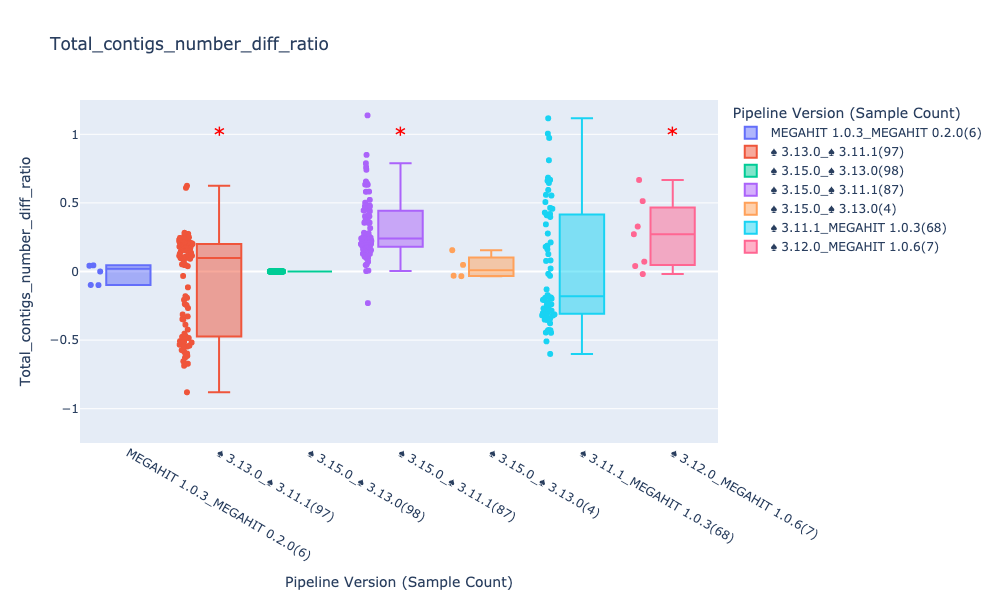

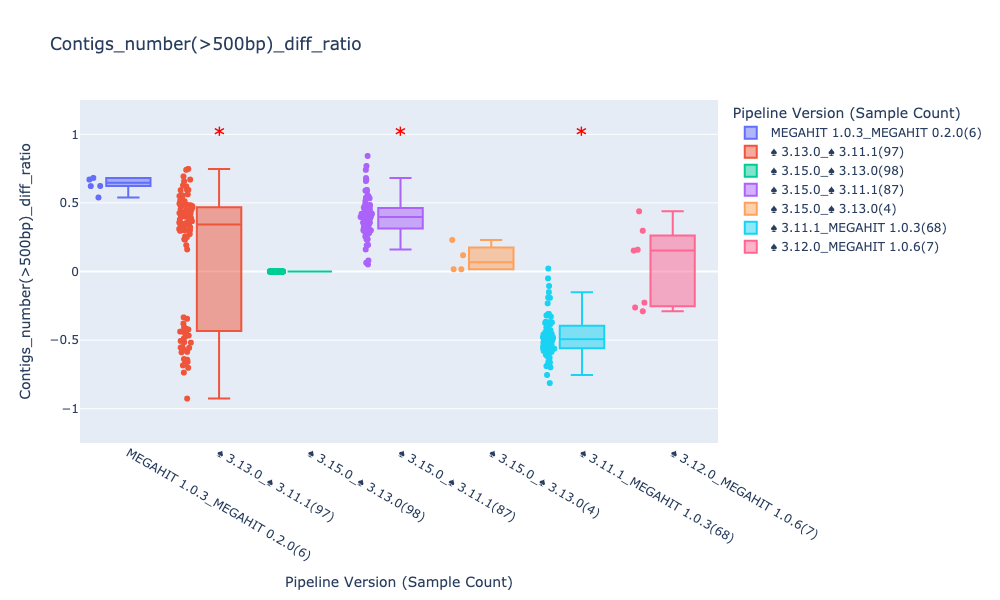

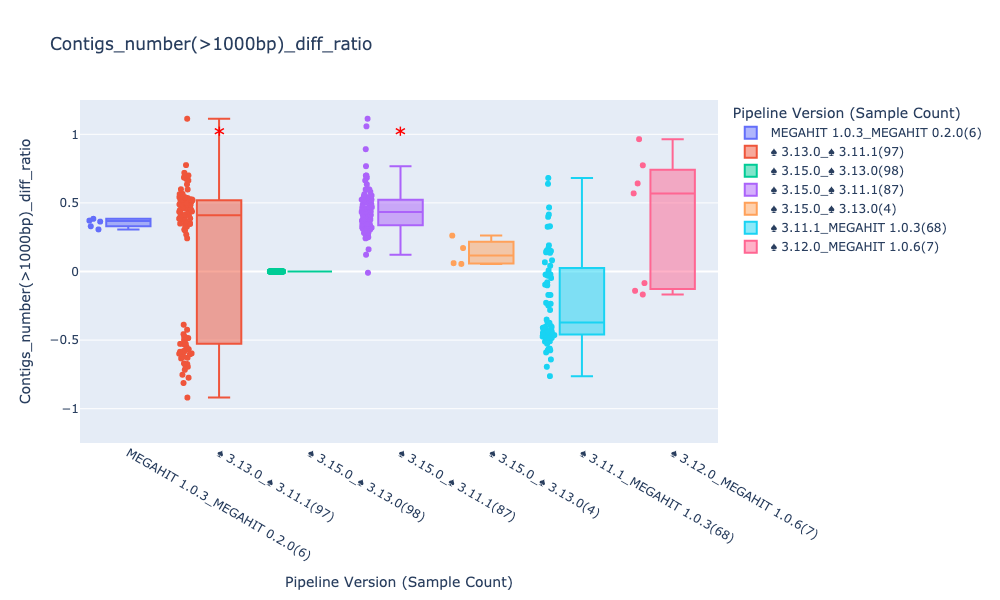

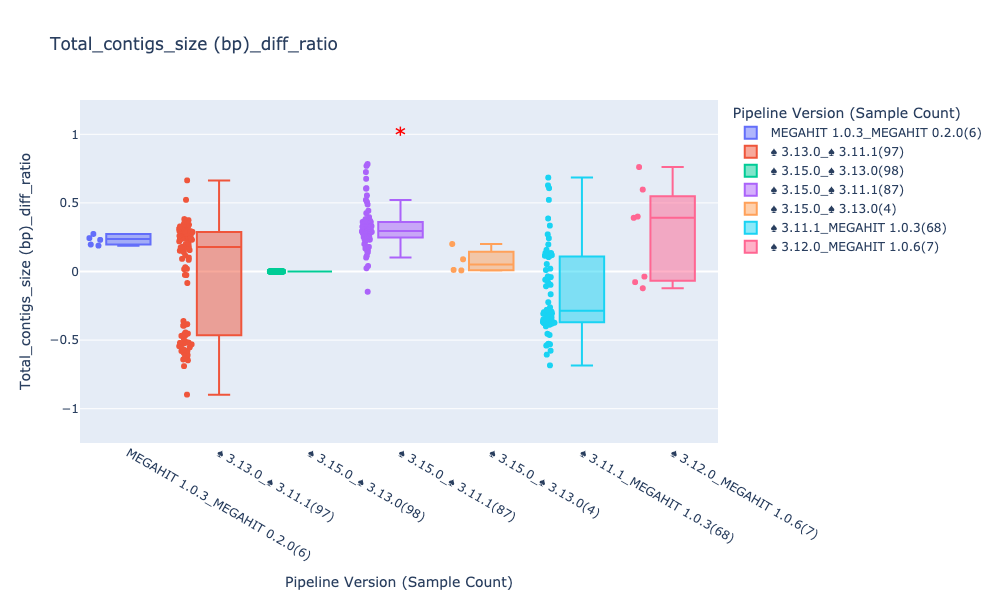

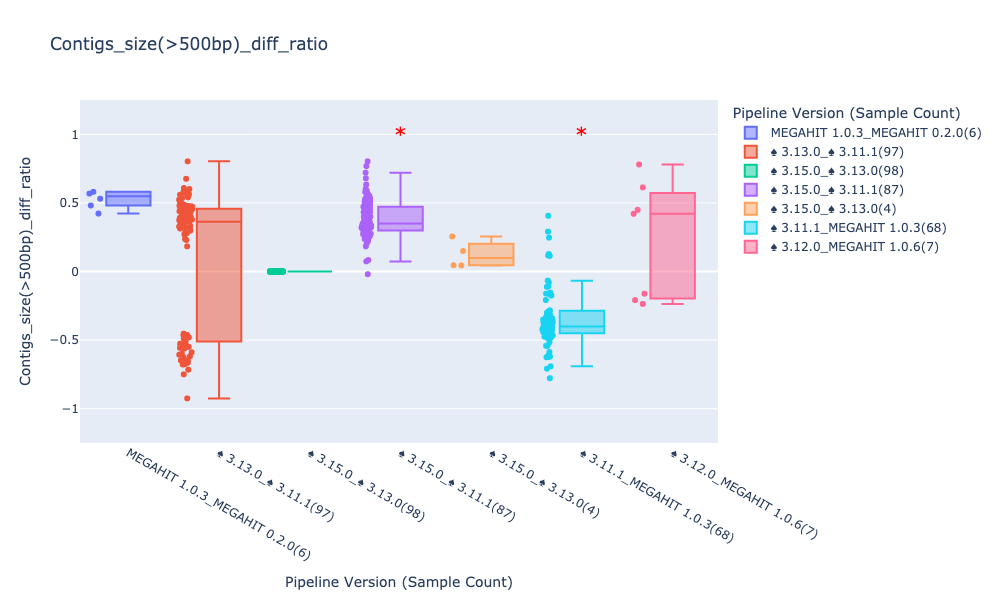

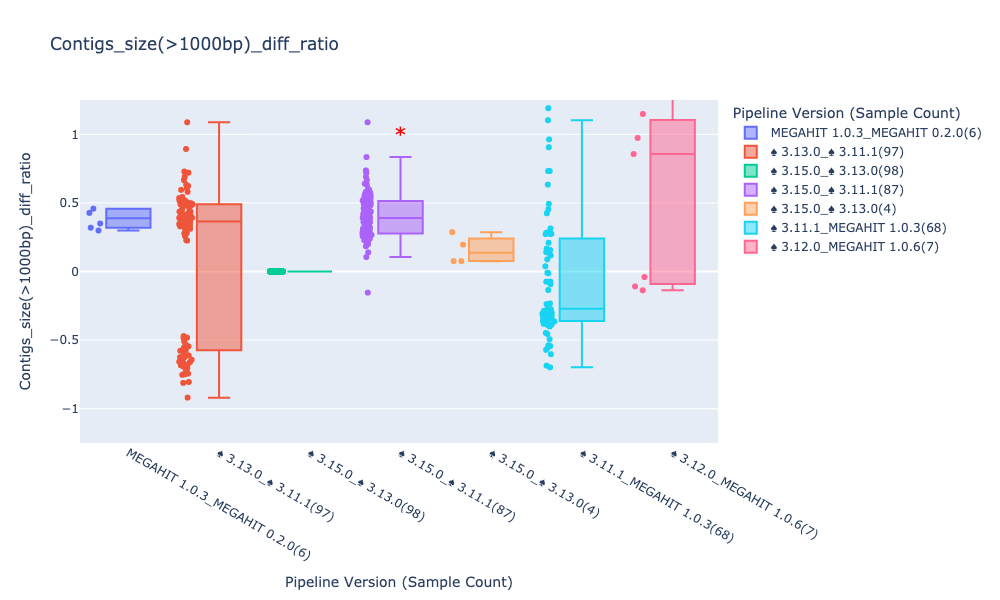

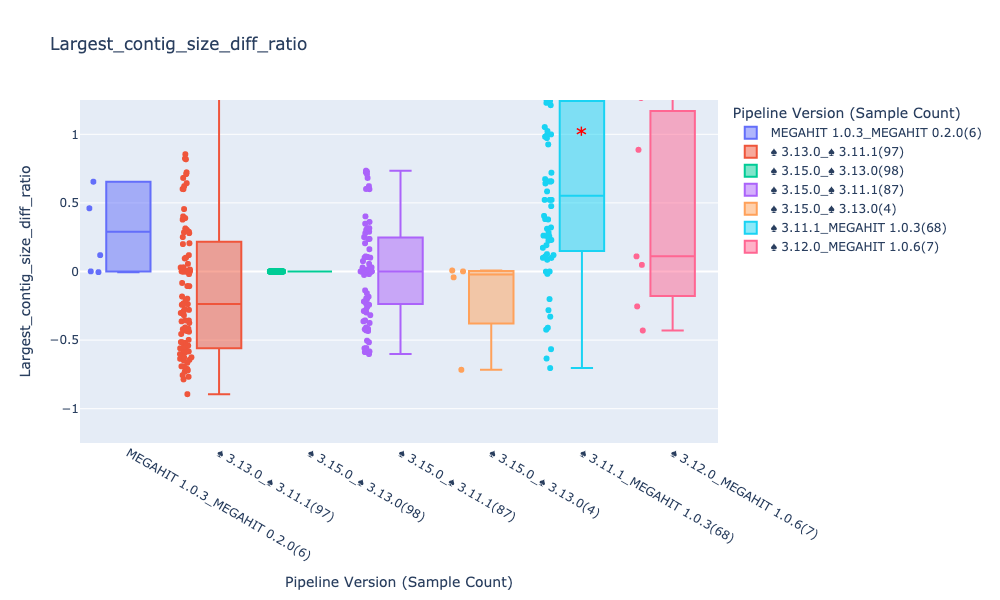

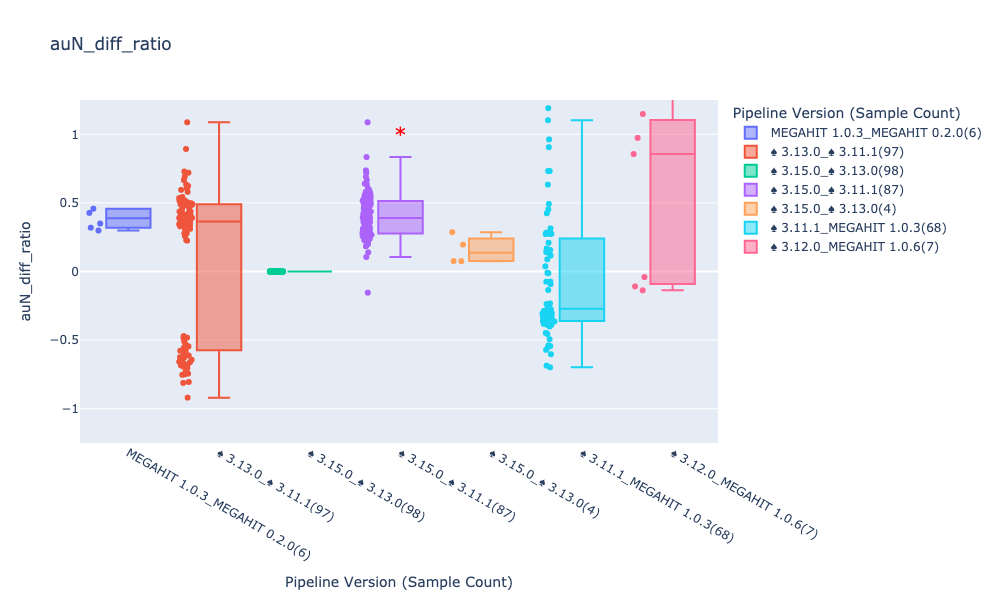

In [6]:
# This script will perform the following steps:
#1. Create box plots to visualize the metric values across pipeline versions.

from itertools import combinations

for metric in ['Total_contigs_number_diff_ratio', 'Contigs_number(>500bp)_diff_ratio', 'Contigs_number(>1000bp)_diff_ratio','Total_contigs_size (bp)_diff_ratio','Contigs_size(>500bp)_diff_ratio','Contigs_size(>1000bp)_diff_ratio','Largest_contig_size_diff_ratio','auN_diff_ratio']:
    metric_data = cleaned_data[cleaned_data['Metric'] == metric]

    fig = px.box(
        metric_data,
        x='Pipeline_with_count',
        y='Value',
        color='Pipeline_with_count',
        title=f"{metric}",
        labels={"Value": metric, "Pipeline_with_count": "Pipeline Version (Sample Count)"},
        points="all",
    )
    fig.update_layout(width=1000, height=600, yaxis_range=[-1.25, 1.25])
    # Add significance markers
    sig_results = results[(results['Metric'] == metric) & (results['significant'])]
    for _, row in sig_results.iterrows():
        fig.add_annotation(
            x=row['Pipeline_with_count'],
            y=1,
            text="*",
            showarrow=False,
            font=dict(size=20, color="red")
        )
    fig.show(renderer="png")

## Summary of assembly analysis

#### Boxplots
- Improvement in newer versions: Generally, newer versions of the assemblers show improvements over older versions for most metrics.
- Most comparisons show statistically significant differences (p < 0.05), as indicated by the red asterisks(*) above the boxes.

#### Contig Number Metrics
- Total_contigs_number_diff_ratio: Most assemblers show a slight improvement (positive median), with metaSPAdes v3.15.0 showing the largest improvement.
- Contigs_number(>500bp)_diff_ratio and Contigs_number(>1000bp)_diff_ratio: Similar trends to total contig number, with modest improvements across versions.

#### Contig Size Metrics
- Total_contigs_size(bp)_diff_ratio: Positive improvements for most assemblers, indicating larger total assembly sizes in newer versions.
- Contigs_size(>500bp)_diff_ratio and Contigs_size(>1000bp)_diff_ratio: Consistent improvements across assemblers, particularly for metaSPAdes.
- Largest_contig_size_diff_ratio: Variable results, with some assemblers showing improvements while others show slight decreases. Not a good metric to use??

#### Assembly Quality Metrics
- auN_diff_ratio: Generally positive improvements, indicating better contiguity in newer versions. ex: The positive mean difference (0.3897) indicates that metaSPAdes v. 3.15.0 generally produces higher auN values compared to SPAdes v. 3.11.1.

#### Conclusion: 
The box plots suggest that newer versions of assembly software, particularly metaSPAdes, exhibits the largest improvements among all assemblers, especially in the latest version (3.15.0) compared to both its previous version and other assemblers. However, the degree of improvement varies, and there is significant sample-to-sample variability. This analysis provides insights for deciding whether to reprocess old data with newer assembler versions.

## Considerations for Reprocessing Samples After a Workflow Update - 2

Determining a specific threshold for reprocessing all samples when a new version of the assembly workflow is released can be challenging. Here are some thoughts and can be expanded or adjusted with further discussion:

1. Focus on key metrics such as contig number, contig size, and assembly quality (e.g., auN).  Consider setting a threshold where the average improvement is above a certain percentage, e.g., 10-15%.
2. Establish a multi-metric threshold: For example, require improvements in at least 3 out of 5 key metrics to trigger reprocessing. Only consider reprocessing if the improvements are statistically significant (p < 0.05).
